In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

print("Missing Values:\n", df.isnull().sum())

print("\nSummary Statistics:\n", df.describe())

Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

In [ ]:
df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [ ]:
df=df.drop(['Date'],axis=1)

In [ ]:
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5
...,...,...,...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,5
6432,45,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,12
6433,45,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


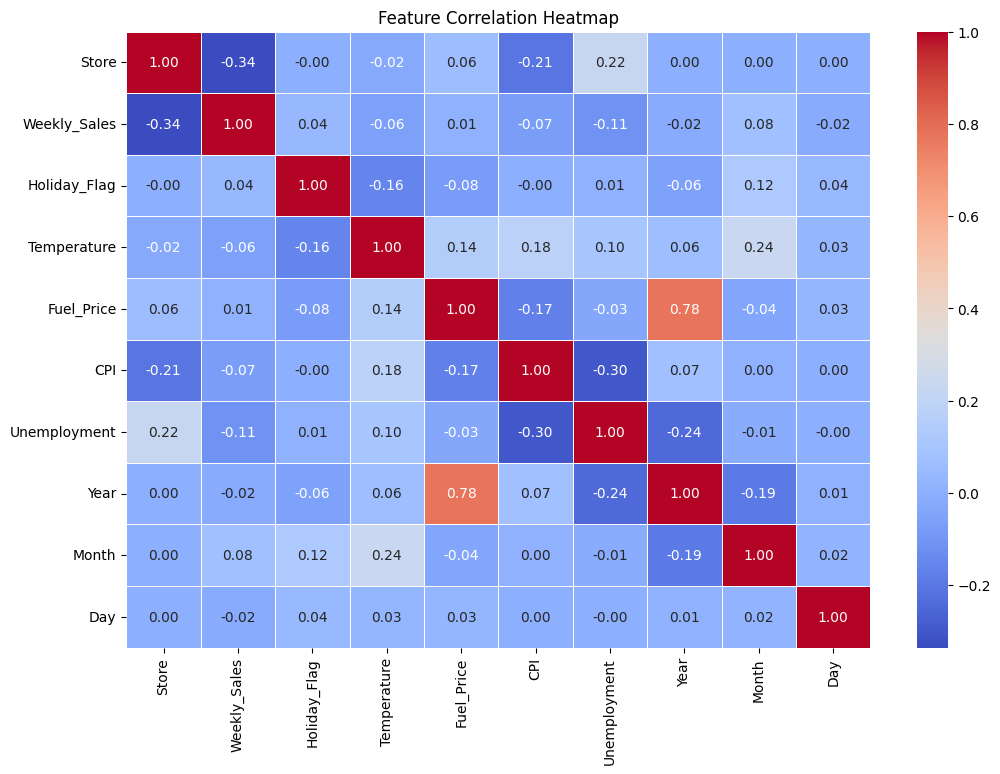

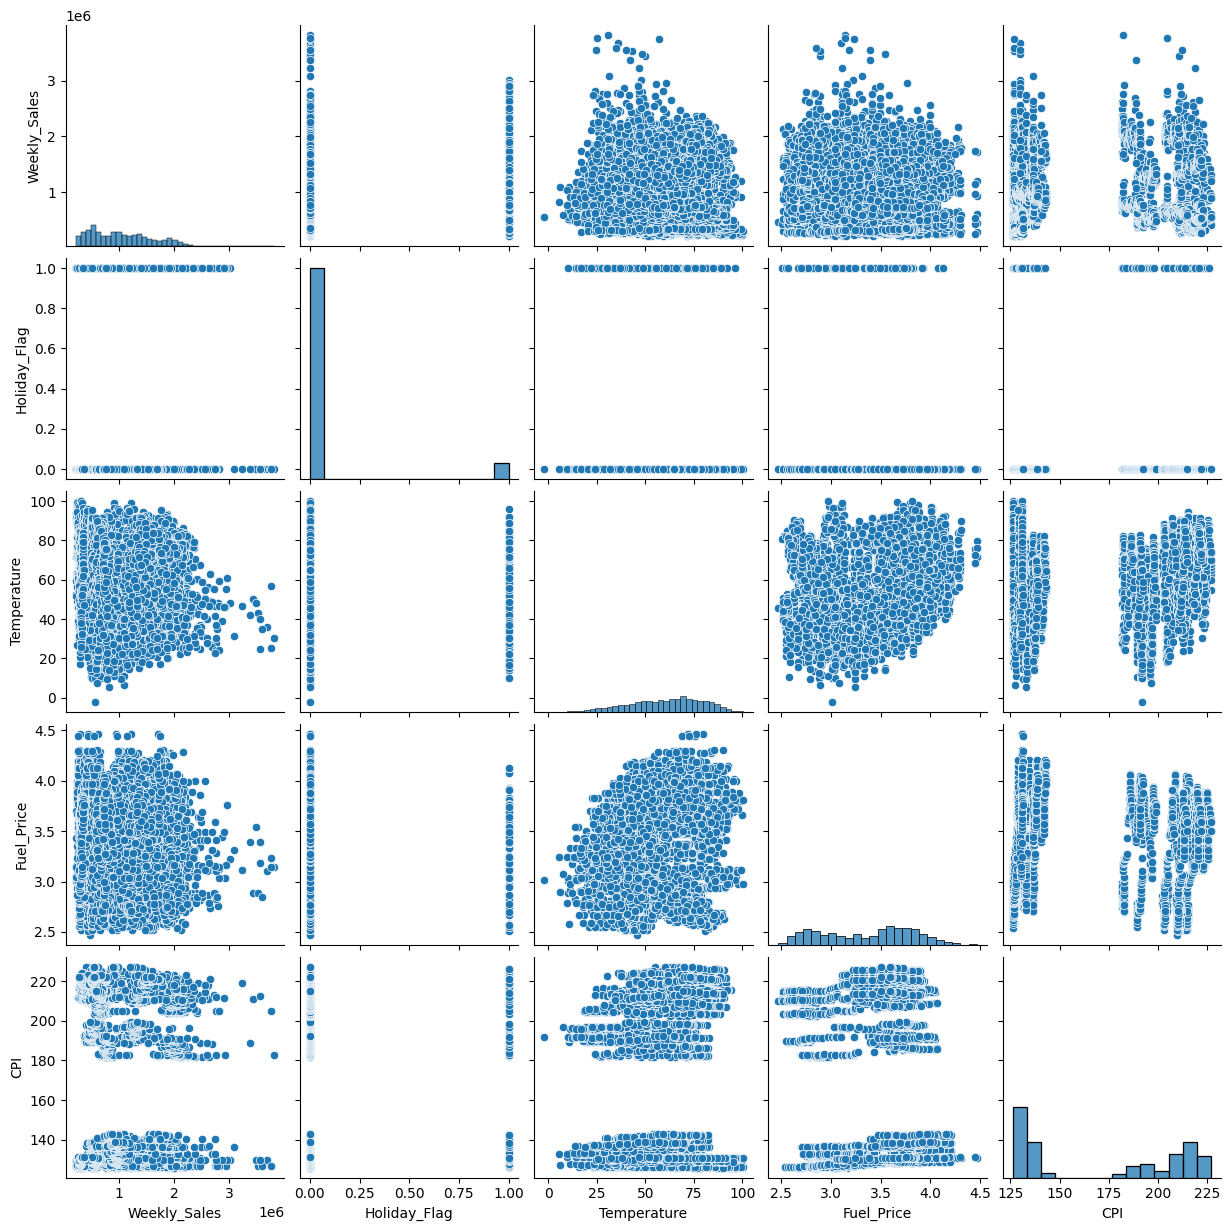

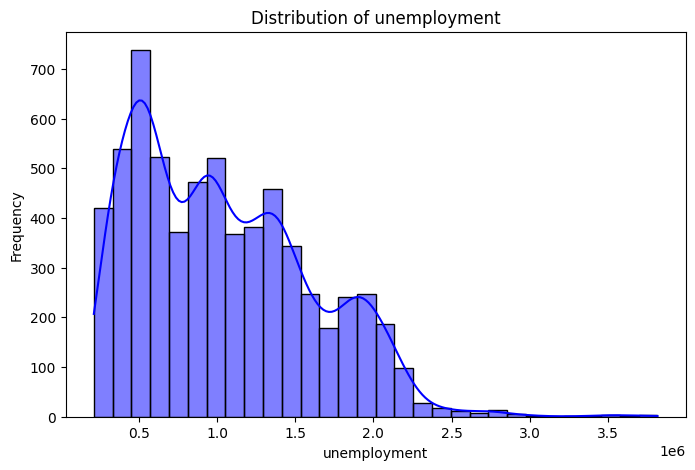

In [ ]:

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")

plt.show()


sns.pairplot(df[['Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI']])
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of unemployment")
plt.xlabel("unemployment")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


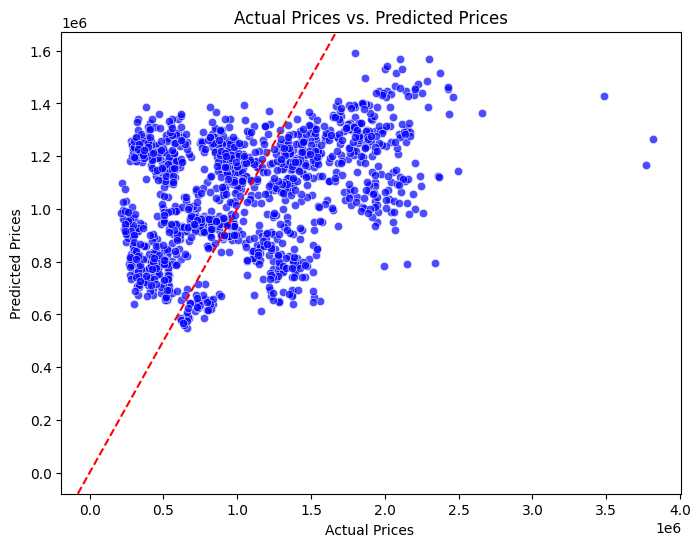

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.xlabel("Actual Prices ")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from scipy.stats import skew


In [ ]:
skewness=df.skew()

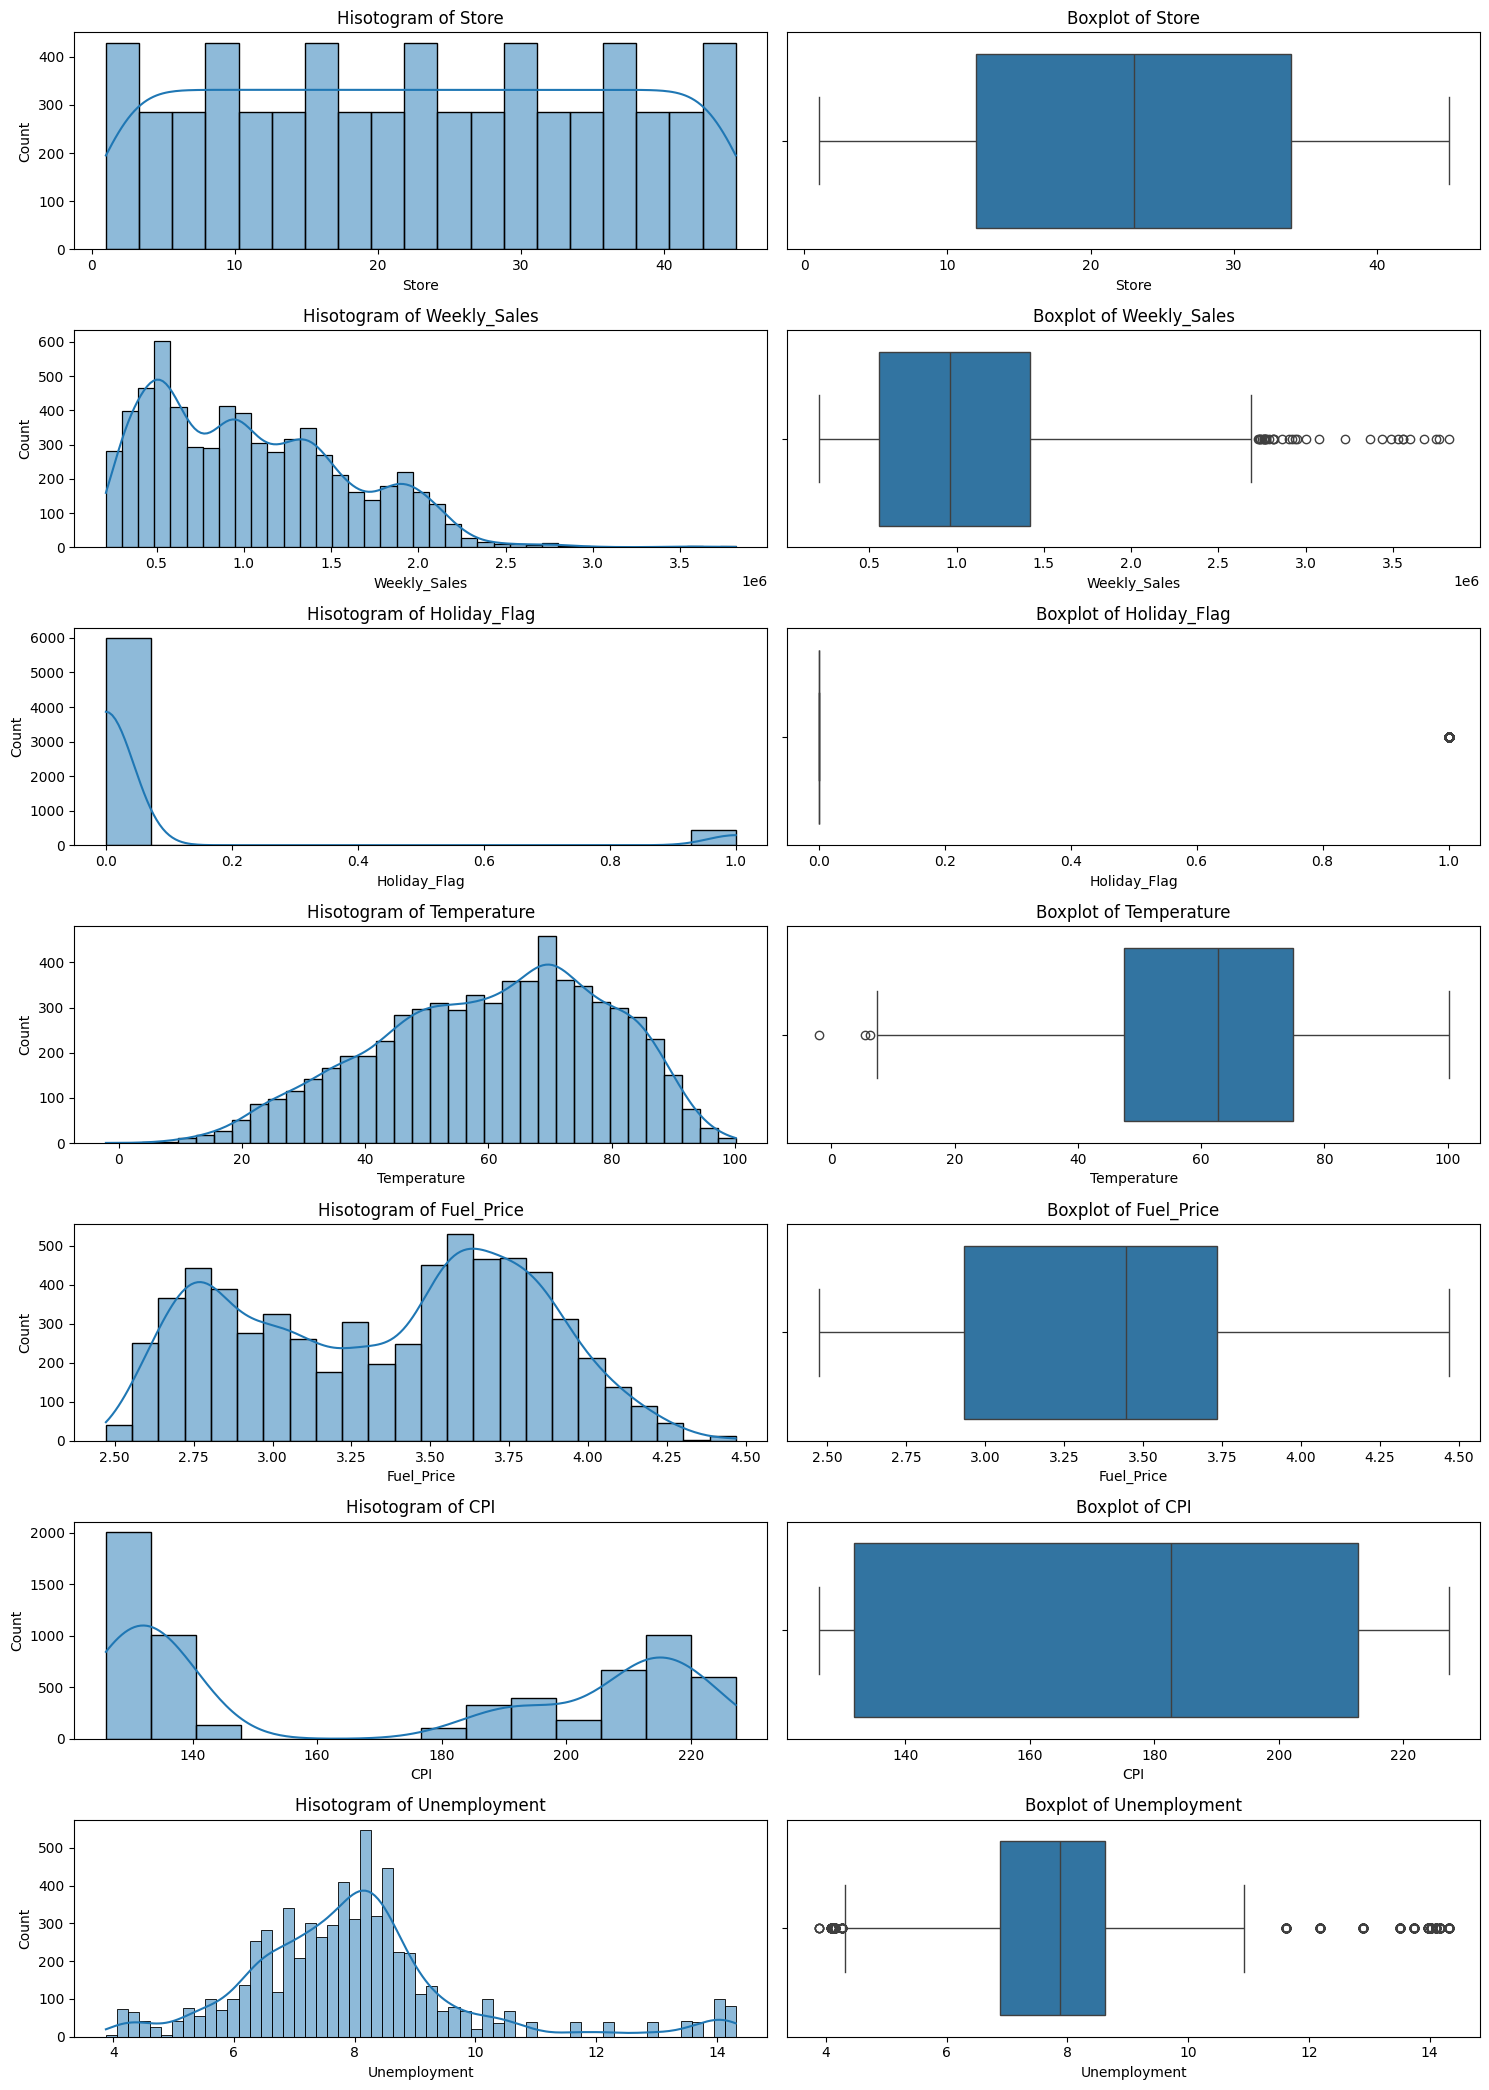

In [ ]:
num_cols=len(df_new.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df_new.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Hisotogram of {col}")
  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [ ]:
skewness=df.skew()
print(skewness)

Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
Year            0.062642
Month           0.039568
Day             0.008512
dtype: float64


In [ ]:
import numpy as np

skewed_cols=df_new.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols< 1].index
print("Highly Skewed Columns:",highly_skewed)
print("Negatively Skewed Columns:",negatively_skewed)


Highly Skewed Columns: Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns: Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [ ]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])


In [ ]:
df.skew()

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991
Year,0.062642
Month,0.039568
Day,0.008512


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=["Weekly_Sales"])
y = df["Weekly_Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1345
RMSE: 0.9423


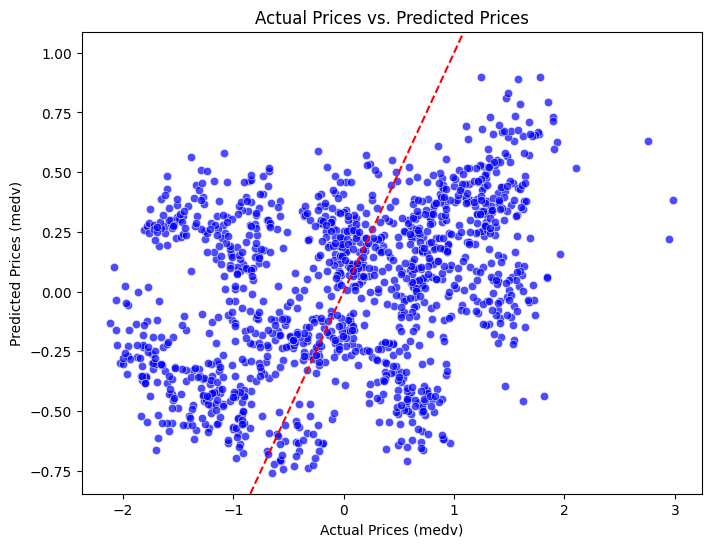

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.xlabel("Actual Prices (medv)")
plt.ylabel("Predicted Prices (medv)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

y_pred=rf_model.predict(X_test)

r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9762
RMSE: 0.1563


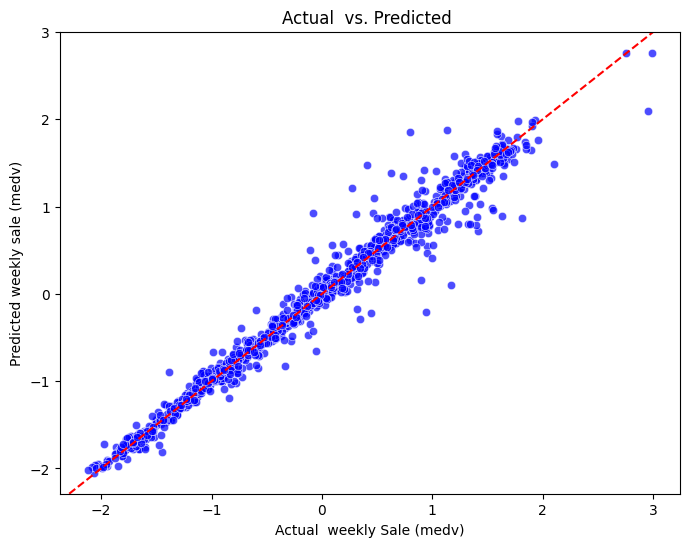

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.xlabel("Actual  weekly Sale (medv)")
plt.ylabel("Predicted weekly sale (medv)")
plt.title("Actual  vs. Predicted ")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [55]:
df


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,-1.942666,1.062778,0.000000,-1.017966,-1.683544,1.006528,2.208934,2010,2,5
1,-1.942666,1.060635,0.693147,-1.204376,-1.732738,1.009450,2.208934,2010,2,12
2,-1.942666,1.023306,0.000000,-1.135341,-1.802251,1.010391,2.208934,2010,2,19
3,-1.942666,0.757367,0.000000,-0.799809,-1.706104,1.011002,2.208934,2010,2,26
4,-1.942666,0.950729,0.000000,-0.806467,-1.574543,1.011613,2.208934,2010,3,5
...,...,...,...,...,...,...,...,...,...,...
6430,1.554160,-0.454488,0.000000,0.186582,1.408278,0.604228,2.270475,2012,9,28
6431,1.554160,-0.408915,0.000000,0.187148,1.380942,0.607706,2.268718,2012,10,5
6432,1.554160,-0.406671,0.000000,-0.388228,1.415115,0.611181,2.268718,2012,10,12
6433,1.554160,-0.443275,0.000000,-0.280200,1.344527,0.611260,2.268718,2012,10,19


In [56]:
import pandas as pd
import numpy as np

Store = 3
Date = '10-12-2014'
Holiday_Flag = 0
Temperature = 50.41
Fuel_Price = 3.701
CPI = 300.096358
Unemployment = 7.106
input_data = {
    'Store': [Store],
    'Date': [Date],
    'Holiday_Flag': [Holiday_Flag],
    'Temperature': [Temperature],
    'Fuel_Price': [Fuel_Price],
    'CPI': [CPI],
    'Unemployment': [Unemployment]
}
sample_df = pd.DataFrame(input_data)
print("Original Sample Data:")
display(sample_df)

Original Sample Data:


,Store,Date,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,3,10-12-2014,0,50.41,3.701,300.096358,7.106


In [57]:
sample_df["Date"] = pd.to_datetime(sample_df["Date"])
sample_df["Year"] = sample_df["Date"].dt.year
sample_df["Month"] = sample_df["Date"].dt.month
sample_df["Day"] = sample_df["Date"].dt.day
sample_df = sample_df.drop(['Date'],axis=1)

In [58]:
prediction = rf_model.predict(sample_df)
print(f"Predicted Class: {prediction[0]}")

Predicted Class: -0.4521733455330386
